In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout



In [4]:
data= pd.read_csv('Google_Stock_Price_Train.csv', thousands=",")
data

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,7380500
1,1/4/2012,331.27,333.87,329.08,666.45,5749400
2,1/5/2012,329.83,330.75,326.89,657.21,6590300
3,1/6/2012,328.34,328.77,323.68,648.24,5405900
4,1/9/2012,322.04,322.29,309.46,620.76,11688800
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,623400
1254,12/27/2016,790.68,797.86,787.66,791.55,789100
1255,12/28/2016,793.70,794.23,783.20,785.05,1153800
1256,12/29/2016,783.33,785.93,778.92,782.79,744300


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   object 
 1   Open    1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Close   1258 non-null   float64
 5   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 59.1+ KB


In [6]:
data['Date']=pd.to_datetime(data['Date'])

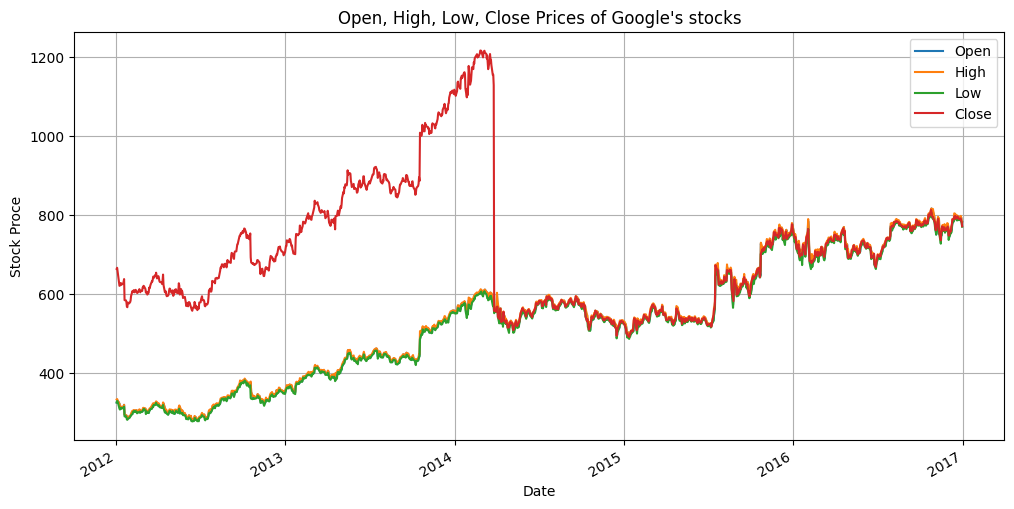

In [7]:
fig = data.plot(
    x="Date",
    y=["Open","High","Low","Close"],
    figsize=(12,6),
    title="Open, High, Low, Close Prices of Google's stocks"
)

fig.set_xlabel("Date")
fig.set_ylabel("Stock Proce")
plt.grid(True)
plt.show()


In [10]:
data = data.drop(['Date'],axis=1)

In [11]:
sc= MinMaxScaler()
data_sc = sc.fit_transform(data) 

In [14]:
def create_sequences(data,target_col_idx,seq_len=60):
    x,y=[],[]
    for i in range(seq_len,len(data)):
        x.append(data[i-seq_len:i])
        y.append(data[i,target_col_idx])
    return np.array(x),np.array(y)
x,y = create_sequences(data_sc,3)

In [15]:
x

array([[[0.08581368, 0.09640129, 0.09044931, 0.23757287, 0.29525831],
        [0.09701243, 0.09834351, 0.09823458, 0.24151427, 0.22993592],
        [0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        ...,
        [0.07846566, 0.07903337, 0.0783452 , 0.21546794, 0.14593512],
        [0.08034452, 0.08276841, 0.08330808, 0.21229828, 0.16105326],
        [0.08497656, 0.08751191, 0.08921806, 0.22430164, 0.20379656]],

       [[0.09701243, 0.09834351, 0.09823458, 0.24151427, 0.22993592],
        [0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        [0.09156187, 0.08881917, 0.08800576, 0.21641884, 0.21617942],
        ...,
        [0.08034452, 0.08276841, 0.08330808, 0.21229828, 0.16105326],
        [0.08497656, 0.08751191, 0.08921806, 0.22430164, 0.20379656],
        [0.08627874, 0.08564439, 0.08283452, 0.21420007, 0.15438526]],

       [[0.09433366, 0.09251685, 0.09408623, 0.22878051, 0.26361233],
        [0.09156187, 0.08881917, 0.08800576, 0.21641884, 0.2

In [16]:
split = int(len(x)*0.8)
x_train,x_test = x[:split], x[split:]
y_train,y_test = y[:split], y[split:]

In [19]:
model=Sequential()
model.add(LSTM(64,return_sequences=True,input_shape=(x_train.shape[1],x_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.1))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 60, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
h = model.fit(
    x_train,y_train,
    epochs=50,
    batch_size=32,
    validation_data=(x_test,y_test)
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 0.0652 - val_loss: 8.9167e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0087 - val_loss: 8.6994e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0086 - val_loss: 0.0065
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0061 - val_loss: 0.0058
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0038 - val_loss: 0.0011
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0042 - val_loss: 6.4468e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0043 - val_loss: 6.6685e-04
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0025 - val_loss: 0.0052
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0043 - val_loss: 0.0032
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0045 - val_loss: 6.1109e-04
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0054 - val_loss: 0.0012
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 6

In [22]:
y_pred = model.predict(x_test)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


In [24]:
close_scaler =MinMaxScaler()
close_scaler.min_,close_scaler.scale_ = sc.min_[3:4],sc.scale_[3:4]

In [25]:
predicted_values = close_scaler.inverse_transform(y_pred)
actual_values = close_scaler.inverse_transform(y_test.reshape(-1,1))

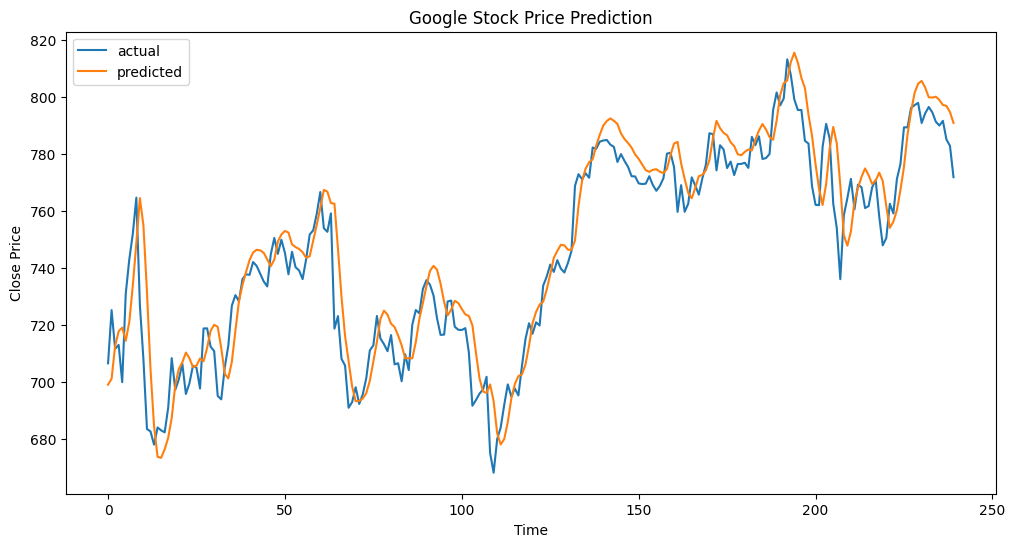

In [26]:

plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='actual')
plt.plot(predicted_values, label='predicted')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [27]:
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = mean_absolute_error(actual_values, predicted_values)
r2 = r2_score(actual_values, predicted_values)

print('RMSE: ', rmse)
print('MAE: ', mae)
print('R2 Score: ', r2)

RMSE:  12.146904281293331
MAE:  9.259757293701176
R2 Score:  0.8764316982835878
